# 1. Correlations from Mismatched Histories

## Predict

**(a)** Pairwise deletion can produce a matrix that is not PSD because different entries are estimated from different subsets of dates. The assembled entries need not be mutually consistent with any single multivariate sample. Complete-case correlation uses one common data matrix for every entry, so it is a Gram-type correlation matrix and is PSD in exact arithmetic.

**(b)** Because `IDX` is almost a fixed linear combination of the four stocks, one direction in the true five-dimensional correlation matrix is nearly redundant. I therefore expect a very small minimum eigenvalue. The matrix is close to the PSD boundary, so even modest pairwise-estimation inconsistencies can push that eigenvalue below zero.

**(c)** Correlations involving `D` should be least reliable because `D` only exists near the end of the sample. Pairs involving both `D` and `C` should be especially weak because `C` also misses foreign-market holidays.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Load the repository-local package from either the repository root or the
# self-contained Assignment2 folder.
for candidate in (Path.cwd(), Path.cwd().parent):
    if (candidate / "risk_management").is_dir():
        sys.path.insert(0, str(candidate))
        break

from risk_management import (
    calculate_returns,
    complete_observation_count,
    copula_log_likelihood_contributions,
    copula_risk_differences,
    correlation_diagnostics,
    covariance_from_correlation,
    delta_normal_var,
    empirical_risk_table,
    ewma_diagnostics,
    expected_joint_tail_count,
    fit_best_margins,
    fit_copula_models,
    fit_market_model,
    frobenius_distance,
    joint_observation_counts,
    joint_tail_counts,
    kurtosis_outlier_sensitivity,
    largest_matrix_movements,
    linear_portfolio_var,
    market_model_summary,
    missing_covariance,
    moments_table,
    normal_risk_table,
    normal_scale_mixture_excess_kurtosis,
    plot_pnl_distributions,
    plot_rank_pairs,
    plot_return_series,
    pnl_from_return_scenarios,
    portfolio_tail_risk_comparison,
    portfolio_variance,
    rank_uniforms,
    regime_volatility,
    repair_correlation_summary,
    sample_moments,
    sample_standard_deviations,
    scaled_joint_tail_counts,
    simulate_copula_returns,
    simulate_market_model,
    smallest_eigenvector_loadings,
    standardized_tail_quantiles,
    strongest_pair_tail_dependence,
    subadditivity_check,
    summarize_log_likelihood_contributions,
    tail_count_model_comparison,
    threshold_event_counts,
    uniforms_from_fitted_margins,
    var_model_comparison,
    var_sampling_noise,
)

data_candidates = (Path.cwd(), Path.cwd() / "Assignment2", Path.cwd().parent / "Assignment2")
DATA = next(
    candidate.resolve()
    for candidate in data_candidates
    if all((candidate / f"problem{number}.csv").exists() for number in range(1, 6))
)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)
plt.rcParams.update({"figure.dpi": 120, "font.size": 9})


In [2]:
p1 = pd.read_csv(DATA / "problem1.csv").set_index("Day")
p1_counts = joint_observation_counts(p1)
display(p1_counts)
print(f"Days on which all five series trade: {complete_observation_count(p1)}")

Series,A,B,C,D,IDX
Series,,,,,
A,242,242,221,93,242
B,242,242,221,93,242
C,221,221,228,83,228
D,93,93,83,96,96
IDX,242,242,228,96,250


Days on which all five series trade: 81


## Fit

In [3]:
p1_diagnostics = correlation_diagnostics(p1)
p1_complete = pd.DataFrame(
    p1_diagnostics["complete"], index=p1.columns, columns=p1.columns
)
p1_pairwise = pd.DataFrame(
    p1_diagnostics["pairwise"], index=p1.columns, columns=p1.columns
)
p1_eigenvalues = pd.DataFrame(
    {
        "Complete case": p1_diagnostics["complete_eigenvalues"],
        "Pairwise": p1_diagnostics["pairwise_eigenvalues"],
    }
)

print("Complete-case correlation")
display(p1_complete.round(6))
print("Pairwise correlation")
display(p1_pairwise.round(6))
print("Eigenvalues")
display(p1_eigenvalues.round(8))
print("Cholesky attempts:")
print("  Complete case:", p1_diagnostics["complete_cholesky_status"])
print("  Pairwise:", p1_diagnostics["pairwise_cholesky_status"])

Complete-case correlation


Series,A,B,C,D,IDX
Series,,,,,
A,1.000000,0.396728,0.246622,0.413553,0.871358
B,0.396728,1.000000,0.316887,0.236053,0.670860
C,0.246622,0.316887,1.000000,0.185180,0.564842
D,0.413553,0.236053,0.185180,1.000000,0.571930
IDX,0.871358,0.670860,0.564842,0.571930,1.000000


Pairwise correlation


Series,A,B,C,D,IDX
Series,,,,,
A,1.000000,0.468626,0.430888,0.438449,0.869584
B,0.468626,1.000000,0.463023,0.276692,0.732867
C,0.430888,0.463023,1.000000,0.184615,0.713575
D,0.438449,0.276692,0.184615,1.000000,0.605691
IDX,0.869584,0.732867,0.713575,0.605691,1.000000


Eigenvalues


,Complete case,Pairwise
0,0.001506,-0.011072
1,0.548345,0.471422
2,0.693320,0.528367
3,0.870441,0.857381
4,2.886388,3.153902


Cholesky attempts:
  Complete case: succeeded
  Pairwise: failed: matrix is not positive semidefinite


In [4]:
p1_tracking_positions = [-0.40, -0.30, -0.20, -0.10, 1.00]
p1_standard_deviations = sample_standard_deviations(
    p1.to_numpy(dtype=float), skip_missing=True
)
p1_pairwise_covariance = covariance_from_correlation(
    p1_diagnostics["pairwise"], p1_standard_deviations
)
p1_raw_tracking_variance = portfolio_variance(
    p1_pairwise_covariance, p1_tracking_positions
)

p1_repairs = repair_correlation_summary(p1_diagnostics["pairwise"])
p1_repair_rows = []
for name, result in p1_repairs.items():
    repaired_covariance = covariance_from_correlation(
        result["matrix"], p1_standard_deviations
    )
    p1_repair_rows.append(
        {
            "Repair": name,
            "Minimum eigenvalue": result["minimum_eigenvalue"],
            "Frobenius distance": result["frobenius_distance"],
            "Tracking variance": portfolio_variance(
                repaired_covariance, p1_tracking_positions
            ),
        }
    )

print(f"Raw pairwise tracking-portfolio variance: {p1_raw_tracking_variance:.10f}")
display(pd.DataFrame(p1_repair_rows).round(10))


Raw pairwise tracking-portfolio variance: -0.0000017994


,Repair,Minimum eigenvalue,Frobenius distance,Tracking variance
0,Rebonato-Jackel,-0.000000e+00,0.016182,6.807000e-07
1,Higham,-1.000000e-09,0.015520,6.788000e-07


In [5]:
p1_higham_movements = largest_matrix_movements(
    p1_diagnostics["pairwise"],
    p1_repairs["Higham"]["matrix"],
    list(p1.columns),
)
p1_negative_mode = smallest_eigenvector_loadings(
    p1_diagnostics["pairwise"], list(p1.columns)
)
p1_estimator_gap = frobenius_distance(
    p1_diagnostics["complete"], p1_diagnostics["pairwise"]
)
print("Largest Higham movements")
display(p1_higham_movements.round(6))
print("Loadings of the pairwise matrix's negative-eigenvalue direction")
display(p1_negative_mode.round(6))
print(f"Complete-case vs pairwise Frobenius gap: {p1_estimator_gap:.6f}")
print(
    "Higham repair Frobenius distance:",
    f"{p1_repairs['Higham']['frobenius_distance']:.6f}",
)

Largest Higham movements

,Pair,Before,After,Change,Absolute Change
0,A-IDX,0.869584,0.862540,-0.007045,0.007045
1,C-IDX,0.713575,0.708810,-0.004765,0.004765
2,B-IDX,0.732867,0.728687,-0.004180,0.004180
3,D-IDX,0.605691,0.601964,-0.003727,0.003727
4,A-C,0.430888,0.433165,0.002277,0.002277


Loadings of the pairwise matrix's negative-eigenvalue direction


,Series,Smallest-Eigenvector Loading,Absolute Loading,Smallest Eigenvalue
0,IDX,0.821733,0.821733,-0.011072
1,A,-0.394277,0.394277,-0.011072
2,C,-0.266853,0.266853,-0.011072
3,B,-0.233578,0.233578,-0.011072
4,D,-0.208642,0.208642,-0.011072


Complete-case vs pairwise Frobenius gap: 0.423935
Higham repair Frobenius distance: 0.015520


## Reconcile

**(g)** The raw pairwise covariance gives the tracking portfolio a variance of **-0.0000017994**. PSD means xᵀΣx ≥ 0 for every position vector x. Here the tracking position itself provides a counterexample, so the negative result is not merely odd economically; it directly proves that the assembled covariance matrix is not PSD.

**(h)** My reliability prediction was only partly aligned with the repair. `D`-related correlations have the fewest observations, but Higham's largest moves are `A-IDX`, `C-IDX`, `B-IDX`, and `D-IDX`. With identity weights, Higham is the nearest-correlation projection under the Frobenius norm; it was not given the pair counts. The correction is driven by the matrix's negative-eigenvalue direction. `IDX` has by far the largest absolute loading in that direction (**0.8217**, versus **0.3943** or less for any stock) because it is nearly collinear with the stock basket. The unit-diagonal constraint then spreads the correction across the `IDX` correlations, explaining why those entries move most.

**(i)** Higham moves the pairwise matrix by only **0.01552** in Frobenius norm. The complete-case and pairwise estimates differ by **0.42393**, about 27 times as much. For this dataset, the choice of estimator matters far more than the choice of repair. Both repairs turn the negative tracking variance into a small positive value near **6.8 × 10⁻⁷**.

# 2. A Volatility Estimate After the Regime Changed

## Predict

The return plot should determine the ranking. Before fitting, I expect the recent high-volatility block to make both EWMA estimates exceed full-sample estimates, with λ = 0.94 largest because it reacts fastest and λ = 0.97 next. For the remaining three, I initially predict equal-weight Normal < historical < Student-t: the Student-t should add tail thickness, while historical VaR should reflect the realized lower tail but dilute the short recent regime over 500 days.

The last roughly **40 days** look different from the preceding observations. A single stationary Normal regime is unlikely to generate both a quiet 460-day body and the visibly wider last 40 days; I expect positive excess kurtosis caused by this scale mixture.

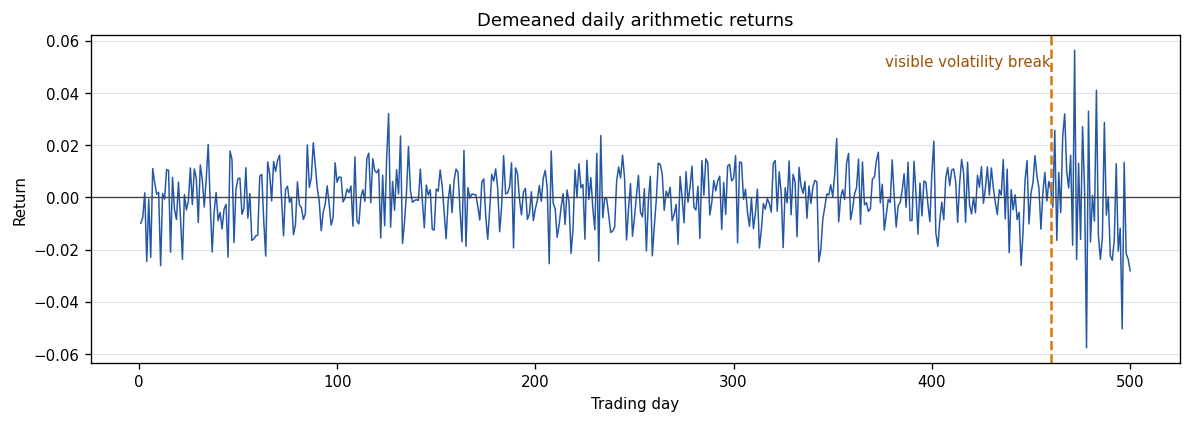

In [6]:
p2_prices = pd.read_csv(DATA / "problem2.csv")
p2_returns = calculate_returns(
    p2_prices, method="DISCRETE", date_column="Day", demean=True
).set_index("Day")["Price"]
plot_return_series(p2_returns, regime_start=460)
plt.show()


In [7]:
p2_ew94 = ewma_diagnostics(p2_returns, 0.94, recent_days=40)
p2_ew97 = ewma_diagnostics(p2_returns, 0.97, recent_days=40)
p2_moments = pd.DataFrame([sample_moments(p2_returns)], index=["Full sample"])
display(pd.DataFrame([p2_ew94, p2_ew97]).round(6))
display(p2_moments.round(6))

,Decay,Volatility,Effective Sample Size,Half Life (days),Weight on Last 40 Days
0,0.94,0.022074,32.333333,11.202306,0.915838
1,0.97,0.020709,65.666635,22.756573,0.704288


,Mean,Variance,Skewness,Excess Kurtosis
Full sample,-0.0,0.000142,-0.156055,2.165942


## Fit

In [8]:
p2_var_table, p2_t_fit = var_model_comparison(
    p2_returns, position_value=1_000_000
)
display(p2_var_table.round(2))
display(
    pd.DataFrame(
        [
            {
                "mu": p2_t_fit.mu,
                "sigma": p2_t_fit.sigma,
                "nu": p2_t_fit.nu,
            }
        ],
        index=["Student-t MLE"],
    ).round(8)
)

,Model,VaR ($)
0,Student-t MLE,18872.44
1,Normal - equal weight,19593.66
2,Historical simulation,20574.46
3,Normal - EWMA lambda=0.97,34063.74
4,Normal - EWMA lambda=0.94,36307.95


,mu,sigma,nu
Student-t MLE,0.000182,0.01029,8.269918


In [9]:
p2_regimes = regime_volatility(p2_returns, recent_days=40)
p2_standardized_quantiles = standardized_tail_quantiles(
    p2_t_fit.nu, alpha=0.05
)
p2_mixture_excess_kurtosis = normal_scale_mixture_excess_kurtosis(p2_regimes)
p2_noise = pd.DataFrame(
    [
        {"Decay": 0.94, **var_sampling_noise(
            p2_ew94["Volatility"],
            p2_ew94["Effective Sample Size"],
            position_value=1_000_000,
        )},
        {"Decay": 0.97, **var_sampling_noise(
            p2_ew97["Volatility"],
            p2_ew97["Effective Sample Size"],
            position_value=1_000_000,
        )},
    ]
)
display(p2_regimes.round(6))
display(p2_standardized_quantiles.round(6))
print(
    "Theoretical excess kurtosis from the two-Normal scale mixture:",
    f"{p2_mixture_excess_kurtosis:.4f}",
)
display(p2_noise.round(6))

,Regime,Observations,Standard Deviation
0,Earlier,460,0.010178
1,Recent,40,0.024289


,Distribution,Lower-tail quantile
0,Normal,-1.644854
1,Student-t (nu=8.2699),-1.612328


Theoretical excess kurtosis from the two-Normal scale mixture: 2.5723


,Decay,Volatility Standard Error,Dollar Volatility Standard Error,Dollar VaR Standard Error
0,0.94,0.002745,2744.948889,4515.039136
1,0.97,0.001807,1807.081509,2972.384575


## Reconcile

**(e)** The two EWMA estimates landed in the predicted order: λ = 0.94 gives **USD 36,307.95**, then λ = 0.97 gives **USD 34,063.74**. Historical VaR is **USD 20,574.46** and equal-weight Normal VaR is **USD 19,593.66**. The surprise is the fitted Student-t at only **USD 18,872.44**, the smallest of all five, so my predicted ordering of the last three models was wrong. The fitted parameters are μ = 0.000182, scale = 0.010290, and ν = 8.27. The direct explanation is quantile geometry: after standardizing both distributions to unit variance, the 5% Student-t quantile is **-1.6123**, less negative than the Normal's **-1.6449**. A t distribution puts more probability near the center and in the far tails, so at this moderately deep 5% cutoff it can have a smaller VaR; its heavy-tail advantage appears farther out. The positive fitted location also slightly reduces loss VaR.

**(f)** The first 460 days have standard deviation about **1.02%**, while the last 40 days have standard deviation about **2.43%**. Treating those as two zero-mean Normal regimes implies theoretical excess kurtosis of **2.57**, close to the observed **2.17**. Thus scale mixing alone nearly explains the sample kurtosis: the fitted Student-t is primarily summarizing a volatility mixture with one unconditional distribution, not showing that every day follows one stable t regime.

**(g)** The two EWMA VaRs differ by about **USD 2,244**. The approximate one-standard-error VaR noise is about **USD 4,515** for λ = 0.94 and **USD 2,972** for λ = 0.97, so the gap is not convincingly larger than estimation noise. These estimates use the same overlapping return history, so their errors are strongly correlated; comparing the gap with a single estimator's standard error does not estimate the standard error of the difference and is likely conservative. The persistent gap mainly reflects the two decay rates' different memory and resulting responsiveness. **Opinion:** I would use λ = 0.94 for a trading limit because it reacts faster to a sudden volatility change, and λ = 0.97 for a capital number because the longer effective sample gives a more stable estimate.

# 3. When Diversification Raises VaR

## Predict

Each bond has a strongly left-skewed, high-kurtosis payoff distribution. The sample skewness is **-4.82** for A and **-4.92** for B, while excess kurtosis is **22.09** and **23.09**, respectively. Most scenarios earn roughly the promised spread, while a small default region creates a very large loss. Normal VaR will smooth over this discontinuity and can be badly misleading.

At the 20% loss threshold, each bond defaults in fewer than 5% of scenarios, but the union of the two default sets can exceed 5%. I therefore predict that 5% VaR will be larger for the diversified portfolio: diversification puts "at least one default" inside the 5% quantile even though either single-name default may remain just outside it. I still expect ES to improve with diversification because ES averages the losses beyond the cutoff and is subadditive.

In [10]:
p3 = pd.read_csv(DATA / "problem3.csv").set_index("Scenario")
p3_moments = moments_table(p3)
p3_events = pd.DataFrame(
    [threshold_event_counts(p3, threshold=-0.20)]
).rename(columns={"All": "Both"})
display(p3_moments.round(6))
display(p3_events)


,A,B
Mean,0.083709,0.085011
Variance,0.018493,0.017451
Skewness,-4.823246,-4.915516
Excess Kurtosis,22.093642,23.086508


,A,B,At least one,Both
0,406,393,782,17


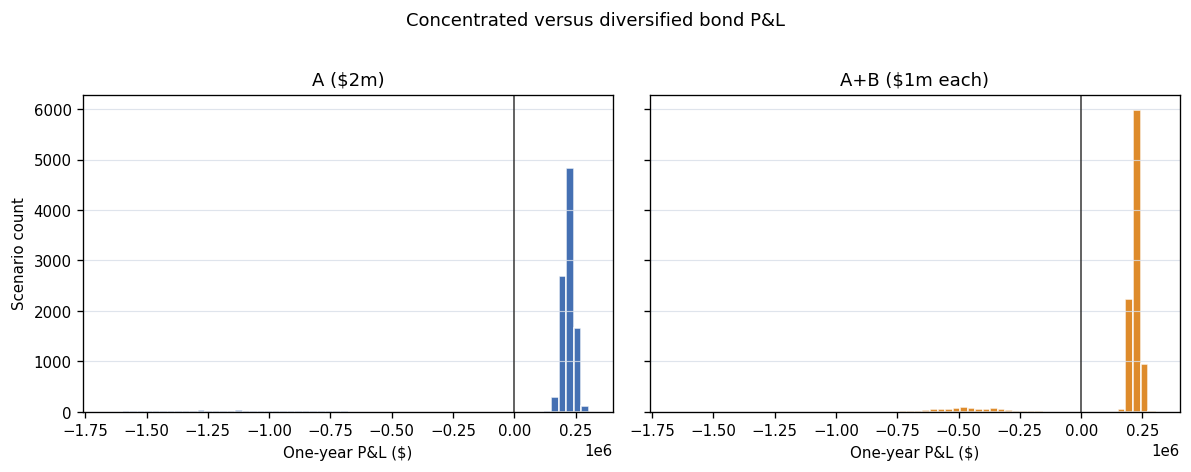

In [11]:
p3_positions = {
    "A ($1m)": {"A": 1_000_000},
    "B ($1m)": {"B": 1_000_000},
    "A ($2m)": {"A": 2_000_000},
    "A+B ($1m each)": {"A": 1_000_000, "B": 1_000_000},
}
p3_pnl = pnl_from_return_scenarios(p3, p3_positions)
plot_pnl_distributions(
    p3_pnl, columns=("A ($2m)", "A+B ($1m each)")
)
plt.show()

## Fit

In [12]:
p3_risk_5 = empirical_risk_table(p3_pnl, alpha=0.05)
p3_normal_5 = normal_risk_table(p3_pnl, alpha=0.05)
p3_risk_1 = empirical_risk_table(p3_pnl, alpha=0.01)
print("Historical risk at 5%")
display(p3_risk_5.round(2))
print("Normal VaR at 5%")
display(p3_normal_5.round(2))
print("Historical risk at 1%")
display(p3_risk_1.round(2))

Historical risk at 5%


,Position,VaR ($),ES ($)
0,A ($1m),-84530.68,443628.30
1,B ($1m),-86011.21,419587.29
2,A ($2m),-169061.35,887256.60
3,A+B ($1m each),414766.85,541997.24


Normal VaR at 5%


,Position,Normal VaR ($)
0,A ($1m),139970.62
1,B ($1m),132276.77
2,A ($2m),279941.24
3,A+B ($1m each),143466.25


Historical risk at 1%


,Position,VaR ($),ES ($)
0,A ($1m),650545.13,709547.78
1,B ($1m),641248.09,700805.34
2,A ($2m),1301090.25,1419095.55
3,A+B ($1m each),598237.15,716407.69


In [13]:
p3_subadditivity_5 = subadditivity_check(
    p3_risk_5,
    component_a="A ($1m)",
    component_b="B ($1m)",
    combined="A+B ($1m each)",
)
display(p3_subadditivity_5.round(2))

,Risk Measure,A + B standalone ($),Combined ($),Subadditive
0,VaR,-170541.89,414766.85,False
1,ES,863215.59,541997.24,True


## Reconcile

**(f)** At 5%, standalone VaRs are **-USD 84,530.68** for A and **-USD 86,011.21** for B; each 5th percentile is still a gain because its default frequency is below 5%. Their sum is **-USD 170,541.89**, while the combined portfolio VaR is a **USD 414,766.85 loss**. VaR therefore fails subadditivity. The mechanism is the union of rare defaults: A has 406 severe-loss scenarios, B has 393, but at least one defaults in 782 scenarios, so the diversified portfolio's default region crosses the 5% cutoff. ES remains subadditive: combined ES is **USD 541,997.24**, below the standalone sum of **USD 863,215.59**.

**(g)** Normal VaR favors the diversified choice: **USD 143,466.25** for USD 1m + USD 1m versus **USD 279,941.24** for USD 2m in A. At the requested 5% historical VaR, that choice is wrong: the concentrated A position has VaR **-USD 169,061.35**, whereas the diversified position has a **USD 414,766.85** loss. Diversification does help for ES and again for 1% VaR, but the Normal model is not right for the right reason—it smooths away the discrete default region that determines whether the 5% quantile crosses into a loss.

**(h)** At 1%, defaults are well inside each single-name tail. VaRs are **USD 650,545.13** for A, **USD 641,248.09** for B, **USD 1,301,090.25** for USD 2m in A, and **USD 598,237.15** for the combination, so diversification lowers VaR and subadditivity holds. VaR's failure is quantile-specific: it appears when the confidence boundary lies between the individual default probabilities and the probability of at least one default.

# 4. Gaussian or Student-t Copula

## Predict

From marginal moments alone, `X1` looks Normal; `X2` and `X3` look Student-t because of their positive excess kurtosis. `X2` has one especially influential observation, so I will check the leave-one-out change before treating its kurtosis as a stable population feature.

Under independence, a particular pair should occupy the same 2.5% tail on only **0.625 days per 1,000**. That is the required baseline for the pre-fit prediction; after fitting, the more informative model comparison is each observed count against the Gaussian- and t-copula implied counts. The rank plots and observed counts should reveal whether the corners are much denser than independence. If they are, I predict the Student-t copula will win because it supports symmetric joint tail dependence while the Gaussian copula does not.

In [14]:
p4 = pd.read_csv(DATA / "problem4.csv")
p4_moments = moments_table(p4)
p4_sensitivity = kurtosis_outlier_sensitivity(p4)
display(p4_moments.round(6))
display(p4_sensitivity.round(6))

,X1,X2,X3
Mean,0.000257,-0.000252,0.000890
Variance,0.000141,0.000261,0.000100
Skewness,-0.034226,-0.615040,0.074066
Excess Kurtosis,-0.117133,7.124957,2.874089


,Series,Full Skewness,Full Excess Kurtosis,Most Influential Row Index,Observation,Skewness Without It,Excess Kurtosis Without It,Kurtosis Absolute Change
0,X1,-0.034226,-0.117133,951,-0.040000,-0.005496,-0.187637,0.070504
1,X2,-0.615040,7.124957,951,-0.142914,0.055867,1.724713,5.400244
2,X3,0.074066,2.874089,951,-0.061244,0.313152,1.730708,1.143381


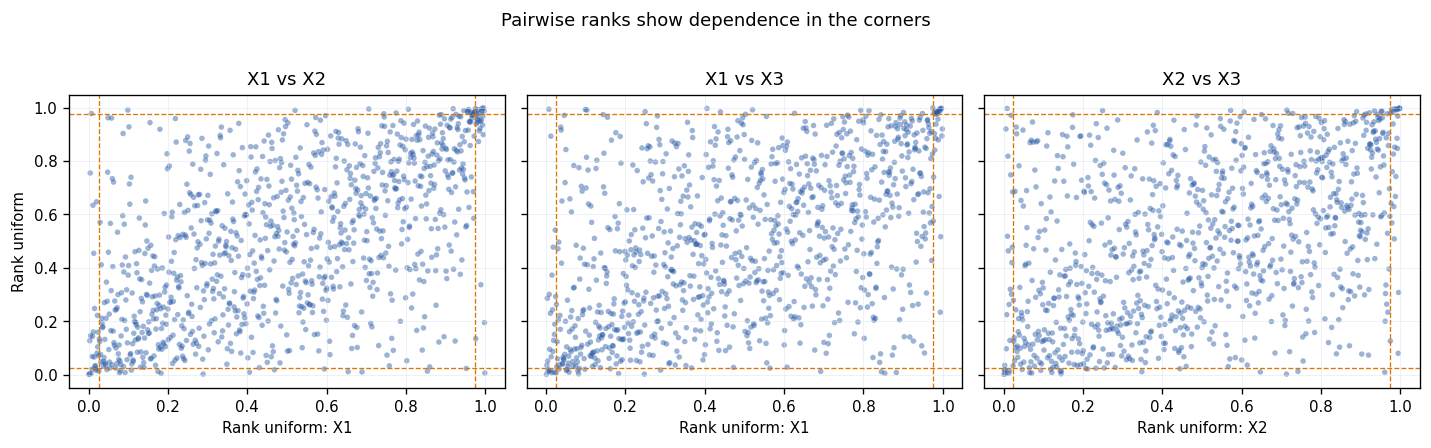

,Pair,Worst Tail Count,Best Tail Count
0,X1-X2,6,8
1,X1-X3,7,12
2,X2-X3,6,9


Expected same-tail count for each pair under independence: 0.625


In [15]:
p4_rank_uniforms = rank_uniforms(p4)
plot_rank_pairs(p4_rank_uniforms)
plt.show()

p4_empirical_tails = joint_tail_counts(
    p4_rank_uniforms, threshold=0.025, labels=list(p4.columns)
)
display(p4_empirical_tails)
print(
    "Expected same-tail count for each pair under independence:",
    f"{expected_joint_tail_count(len(p4), threshold=0.025):.3f}",
)

## Fit

In [16]:
p4_margin_table, p4_margins = fit_best_margins(p4)
p4_uniforms = uniforms_from_fitted_margins(p4, p4_margins)
p4_copula_table, p4_copulas = fit_copula_models(p4_uniforms)
print("Marginal selection")
display(p4_margin_table.round(6))
print("Copula selection")
display(p4_copula_table.round(6))

Marginal selection


,Series,Normal AICc,Student-t AICc,Winner,Student-t nu
0,X1,-6022.536012,-6020.524452,Normal,9.884359e+08
1,X2,-5408.493536,-5518.184759,Student-t,5.271506e+00
2,X3,-6365.690739,-6428.015517,Student-t,6.094916e+00


Copula selection


,Copula,Log Likelihood,nu,AICc,BIC
0,Gaussian,350.453599,NaN,-694.883102,-680.183933
1,Student-t,451.998720,3.658463,-895.957238,-876.366418


In [17]:
p4_simulations = simulate_copula_returns(
    p4_copulas,
    p4_margins,
    list(p4.columns),
    n_samples=100_000,
    seed=545,
)
p4_risk = portfolio_tail_risk_comparison(
    p4,
    p4_simulations,
    position_values=[1_000_000, 1_000_000, 1_000_000],
    alphas=(0.05, 0.01),
)
p4_risk_changes = copula_risk_differences(p4_risk)
display(p4_risk.round(2))
display(p4_risk_changes.round(2))

,Source,Alpha,VaR ($),ES ($)
0,Historical,0.05,47939.19,65698.80
1,Historical,0.01,70092.00,102424.22
2,Gaussian copula,0.05,49605.33,66529.98
3,Gaussian copula,0.01,76142.45,93619.95
4,Student-t copula,0.05,49387.48,68976.18
5,Student-t copula,0.01,80453.14,102110.66


,Alpha,t minus Gaussian VaR ($),t minus Gaussian ES ($)
0,0.05,-217.85,2446.20
1,0.01,4310.69,8490.71


In [18]:
p4_gaussian_tails = scaled_joint_tail_counts(
    p4_simulations["gaussian_uniforms"],
    reference_observations=1_000,
    threshold=0.025,
    labels=list(p4.columns),
)
p4_t_tails = scaled_joint_tail_counts(
    p4_simulations["t_uniforms"],
    reference_observations=1_000,
    threshold=0.025,
    labels=list(p4.columns),
)
p4_tail_comparison = tail_count_model_comparison(
    p4_empirical_tails, p4_gaussian_tails, p4_t_tails
)
display(p4_tail_comparison.round(2))

,Pair,Tail,Observed,Gaussian,Student-t,Gaussian Absolute Error,Student-t Absolute Error
0,X1-X2,Worst,6,6.35,10.18,0.35,4.18
1,X1-X2,Best,8,5.91,9.50,2.09,1.50
2,X1-X3,Worst,7,4.57,8.72,2.43,1.72
3,X1-X3,Best,12,4.66,7.65,7.34,4.35
4,X2-X3,Worst,6,4.08,7.92,1.92,1.92
5,X2-X3,Best,9,4.12,7.51,4.88,1.49


In [19]:
p4_ll_rows = copula_log_likelihood_contributions(p4_uniforms, p4_copulas)
p4_ll_summary = summarize_log_likelihood_contributions(p4_ll_rows)
p4_tail_dependence = strongest_pair_tail_dependence(
    p4_copulas, list(p4.columns)
)
display(pd.DataFrame([p4_ll_summary]).round(6))
display(pd.DataFrame([p4_tail_dependence]).round(6))

,Total t-minus-Gaussian Log Likelihood,Contribution With No Series in Outer 5%,Fraction From Non-Outer-5% Days,Fraction of Days With No Series in Outer 5%,Average Contribution per Non-Outer-5% Day,Average Contribution per Outer-5% Day,Outer-to-Non-Outer Average Contribution Ratio
0,101.54512,50.518221,0.497495,0.793,0.063705,0.246507,3.869492


,Pair,rho,Student-t Tail Dependence,Gaussian Tail Dependence
0,X1-X2,0.583263,0.322026,0.0


## Reconcile

**(a)** The fitted margins agree with the initial choices: Normal for `X1`, Student-t for `X2` and `X3`. The Student-t fit for `X1` has ν ≈ **9.88 × 10^8**, which is the numerical ν → ∞ Normal limit and not a fitting bug; AICc accordingly selects the simpler Normal margin. Row index 951 is influential for all three series. Removing it reduces `X2` excess kurtosis from **7.12** to **1.72** and `X3` from **2.87** to **1.73**; both remain positively leptokurtic, so the Student-t choices still stand. `X2` skewness changes from **-0.615** to **0.056**, showing that its apparent negative skew is largely driven by that same observation.

**(g)** The Student-t copula wins decisively on the full likelihood: log likelihood **451.999** versus **350.454**, ΔLL = **101.545**; AICc **-895.96** versus **-694.88**, an advantage of about **201.07**; and BIC **-876.37** versus **-680.18**. Its fitted degrees of freedom are **3.66**. The six empirical same-tail count comparisons are descriptive but mixed: for the `X1-X2` worst tail, the observed count is 6, the Gaussian gives 6.35, and the t copula gives 10.18, so Gaussian is clearly closer there. The t copula is closer in four of the other five pair-tail cells, with one near tie. Because the observed counts are only 6–12, their sampling noise is several events; the likelihood and information-criterion gaps are much stronger evidence for model selection than declaring a winner from these sparse counts alone.

**(h)** The largest copula-driven movement is **1% ES**, which rises by about **USD 8,491** under the t copula. The 1% VaR rises by about **USD 4,311**, and 5% ES by about **USD 2,446**. The 5% VaR changes by only about **-USD 218**. Dependence in extreme joint tails matters most for the average of the worst 1% outcomes; the 5% quantile is farther inside the distribution, where both copulas have nearly the same rank correlation and therefore a similar cutoff.

**(i)** There are **793 of 1,000 days (79.3%)** on which no series lies in its outer 5%. They contribute **50.52** of the **101.55** total t-minus-Gaussian log-likelihood gain, or **49.75%**. Thus the fit improvement is not confined to labeled tail days, but the remaining 207 outer-tail days contribute much more per observation: about **0.2465** versus **0.0637**, a ratio near **3.87**. Information criteria score the entire density; their decisive preference for the t copula is not, by itself, proof of asymptotic tail dependence. The fitted t model's nonzero tail-dependence coefficient and its adequacy in the extremes are separate model implications to inspect.

**(j)** The most correlated pair is `X1-X2`, with ρ ≈ 0.5833. Under the fitted t copula its symmetric tail-dependence coefficient is about **0.3220**. Under a nondegenerate Gaussian copula it is **0** asymptotically.

# 5. Model-Based Simulation and Residual Correlation

## Predict

If the stocks share an omitted industry factor, their residual correlation should be positive. In the portfolio variance expression, the residual cross term has a positive sign for `P1` because both exposures are long, so setting it to zero should **understate** `P1` VaR. For `P2`, the exposures have opposite signs, so the same positive covariance is a hedge; setting it to zero should **overstate** `P2` VaR. I expect the long-short portfolio to be more sensitive in percentage terms because its market exposures largely offset, leaving residual dependence as a larger share of total variance.

## Fit

In [20]:
p5_prices = pd.read_csv(DATA / "problem5.csv")
p5_returns = calculate_returns(
    p5_prices, method="DISCRETE", date_column="Day"
).set_index("Day")
p5_fits = {
    "A": fit_market_model(p5_returns["A"], p5_returns["MKT"]),
    "B": fit_market_model(p5_returns["B"], p5_returns["MKT"]),
}
p5_fit_table, p5_residual_correlations = market_model_summary(p5_fits)
p5_residual_correlation = p5_residual_correlations.loc["A", "B"]
display(p5_fit_table.round(8))
print(f"Residual correlation: {p5_residual_correlation:.6f}")


,Asset,alpha,beta,Residual Standard Deviation
0,A,0.000205,1.035278,0.012888
1,B,0.000315,0.935417,0.011538


Residual correlation: 0.698307


In [21]:
p5_positions = {
    "P1 long A + long B": [1_000_000, 1_000_000],
    "P2 long A - short B": [1_000_000, -1_000_000],
}
p5_full_returns, p5_full_residual_covariance = simulate_market_model(
    p5_returns["MKT"],
    p5_fits,
    n_samples=100_000,
    seed=545,
    include_residual_correlation=True,
)
p5_independent_returns, p5_independent_residual_covariance = simulate_market_model(
    p5_returns["MKT"],
    p5_fits,
    n_samples=100_000,
    seed=545,
    include_residual_correlation=False,
)
p5_full_var = linear_portfolio_var(p5_full_returns, p5_positions)
p5_independent_var = linear_portfolio_var(p5_independent_returns, p5_positions)
print("Residual covariance used in the full model")
display(pd.DataFrame(
    p5_full_residual_covariance,
    index=["A residual", "B residual"],
    columns=["A residual", "B residual"],
).round(8))
print("VaR with full residual covariance")
display(p5_full_var.round(2))
print("VaR with residual off-diagonal set to zero")
display(p5_independent_var.round(2))

Residual covariance used in the full model


,A residual,B residual
A residual,0.000166,0.000104
B residual,0.000104,0.000133


VaR with full residual covariance


,Portfolio,VaR ($)
0,P1 long A + long B,50286.25
1,P2 long A - short B,15746.85


VaR with residual off-diagonal set to zero


,Portfolio,VaR ($)
0,P1 long A + long B,44363.73
1,P2 long A - short B,28253.64


In [22]:
p5_return_covariance = missing_covariance(
    p5_returns[["A", "B"]].to_numpy(dtype=float),
    skip_missing=True,
    correlation=False,
)
p5_delta_var = delta_normal_var(p5_return_covariance, p5_positions)
display(p5_delta_var.round(2))


,Portfolio,Delta-normal VaR ($)
0,P1 long A + long B,50414.62
1,P2 long A - short B,15833.60


## Reconcile

**(e)** The estimated residual correlation is strongly positive at **0.6983**. Keeping it gives `P1` VaR of **USD 50,286.25**; forcing residual independence lowers that to **USD 44,363.73**, so the shortcut understates the long-long risk exactly as predicted. For `P2`, keeping the covariance gives **USD 15,746.85**, while independence raises VaR to **USD 28,253.64**; the shortcut destroys an important hedge and overstates risk. `P2` is much more exposed proportionally because A and B have similar market betas, so their market components mostly cancel in the long-short position.

**(f)** Delta-normal VaRs are **USD 50,414.62** for `P1` and **USD 15,833.60** for `P2`, extremely close to the full residual-covariance simulation. The simulation deliberately uses a zero-mean Normal market shock and zero-mean residual vector and builds stock returns as β times the market shock plus the residual; the reported OLS α values are not added, consistent with the problem's zero-expected-return assumption. Under OLS, residuals are orthogonal to the included market regressor in sample. With a jointly Normal market and residual vector, the linear factor construction is itself jointly Normal, and its covariance reproduces the sample stock covariance apart from simulation error and tiny mean conventions. The two approaches would stop agreeing with nonlinear payoffs, non-Normal or state-dependent residuals, time-varying betas/volatility, omitted-factor dependence not captured by a stable covariance, or a simulation model whose moments differ from the sample covariance.

## Takeaways

1. Missing-data handling is a modeling choice, not a clerical detail: pairwise deletion can create an impossible covariance structure when the true matrix is nearly singular.
2. A volatility model's memory must match its use. Fast decay reacts to breaks; slower decay reduces estimation noise. At a 5% cutoff, a unit-variance Student-t can have a less extreme quantile than a Normal even though its far tails are heavier.
3. VaR can favor the wrong portfolio when the confidence boundary sits near discrete-event probabilities; here Normal VaR misses the 5% historical reversal, while ES remains subadditive.
4. The t copula wins strongly on likelihood and information criteria, but sparse corner counts are noisy and the model-selection win alone does not prove tail dependence.
5. Residual covariance is economically directional: it increases long-long risk and can be the main hedge in a long-short portfolio.